In [2]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv('Salary Data.csv')   # Change filename if needed

print("First 5 Rows")
print(df.head()

print("\nDataset Shape:")
print(df.shape)

print("\nInformation")
print(df.info())


First 5 Rows
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

Dataset Shape:
(375, 6)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years

In [3]:
# ==============================
# MISSING VALUES
# ==============================

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# Numerical Columns
num_cols = ['Age', 'Years of Experience', 'Salary']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = ['Gender', 'Education Level', 'Job Title']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())



Missing Values Before Cleaning
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Missing Values After Cleaning
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


C:\Users\arooj\AppData\Local\Temp\ipykernel_3948\1290002630.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\arooj\AppData\Local\Temp\ipykernel_3948\1290002630.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [4]:

# ==============================
# REMOVE DUPLICATES
# ==============================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)




Duplicate Rows: 50
Shape After Removing Duplicates: (325, 6)


In [5]:

# ==============================
# SUMMARY STATISTICS
# ==============================

print("\nSummary Statistics")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))


Summary Statistics
              Age  Years of Experience         Salary
count  325.000000           325.000000     325.000000
mean    37.378462            10.055385   99970.307692
std      7.175156             6.640458   48577.919969
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.000000            16.000000  140000.000000
max     53.000000            25.000000  250000.000000

Categorical Summary
       Gender Education Level              Job Title
count     325             325                    325
unique      2               3                    174
top      Male      Bachelor's  Director of Marketing
freq      171             192                      9


In [6]:
# ==============================
# OUTLIER DETECTION & HANDLING
# (IQR Method)
# ==============================

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers handled successfully.")


Outliers handled successfully.


In [7]:
# ==============================
# ENCODE CATEGORICAL VARIABLES
# ==============================

encoded_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nEncoded Dataset")
print(encoded_df.head())


Encoded Dataset
    Age  Years of Experience    Salary  Gender_Male  Education Level_Master's  \
0  32.0                  5.0   90000.0         True                     False   
1  28.0                  3.0   65000.0        False                      True   
2  45.0                 15.0  150000.0         True                     False   
3  36.0                  7.0   60000.0        False                     False   
4  52.0                 20.0  200000.0         True                      True   

   Education Level_PhD  Job Title_Accountant  \
0                False                 False   
1                False                 False   
2                 True                 False   
3                False                 False   
4                False                 False   

   Job Title_Administrative Assistant  Job Title_Business Analyst  \
0                               False                       False   
1                               False                       False   


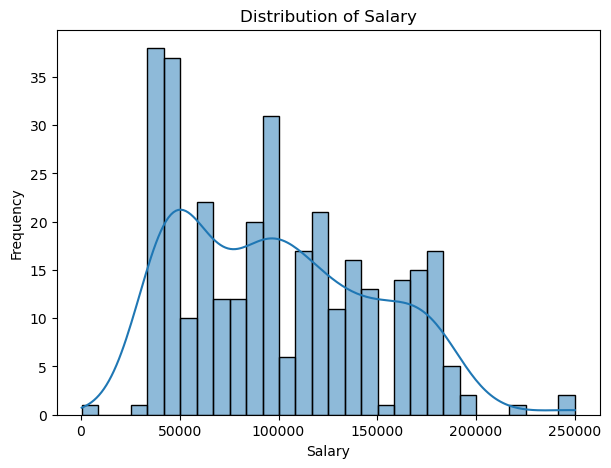

In [8]:
# ===========================================
# Visualization 1: Salary Distribution
# Purpose:
# Shows how salaries are distributed among employees.
# Helps identify whether salary follows a normal distribution
# and whether there are any skewed values.
# ===========================================

plt.figure(figsize=(7,5))
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

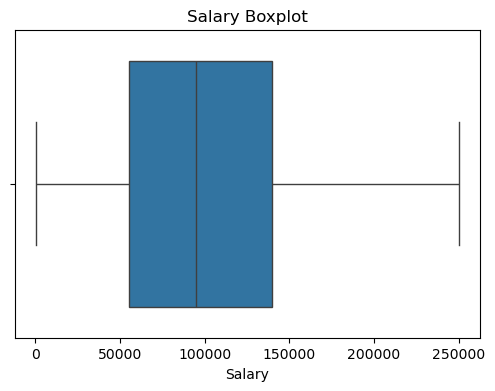

In [9]:
# ===========================================
# Visualization 2: Salary Boxplot
# Purpose:
# Displays the spread of salary values and helps
# identify potential outliers after data cleaning.
# ===========================================

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary Boxplot")
plt.show()

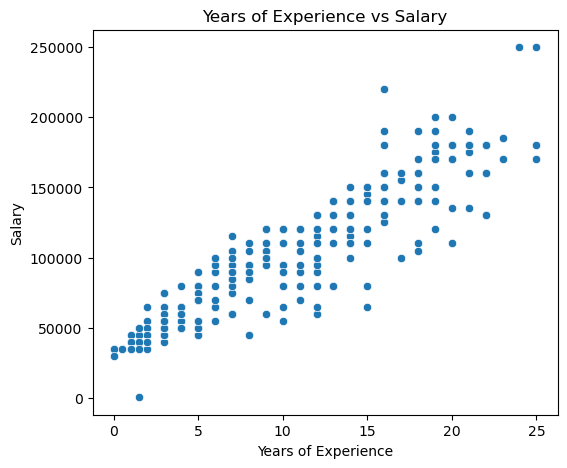

In [10]:
# ===========================================
# Visualization 3: Experience vs Salary
# Purpose:
# Examines the relationship between years of
# experience and salary. A positive trend
# suggests that salary increases with experience.
# ===========================================

plt.figure(figsize=(6,5))
sns.scatterplot(x='Years of Experience', y='Salary', data=df)
plt.title("Years of Experience vs Salary")
plt.show()

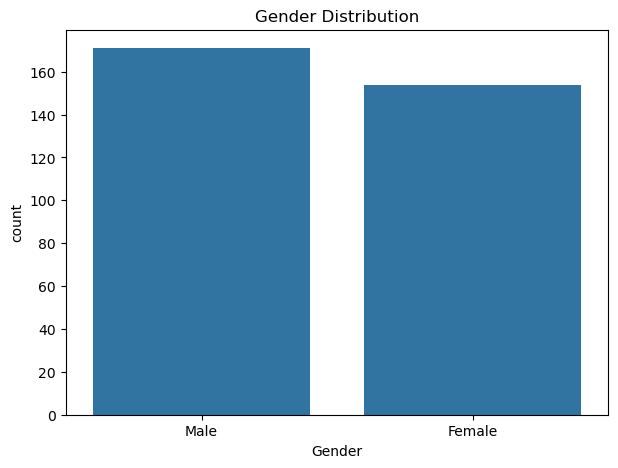

In [11]:
# ===========================================
# Visualization 5: Gender Distribution
# Purpose:
# Displays the number of employees in each
# gender category.
# ===========================================

plt.figure(figsize=(7,5))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

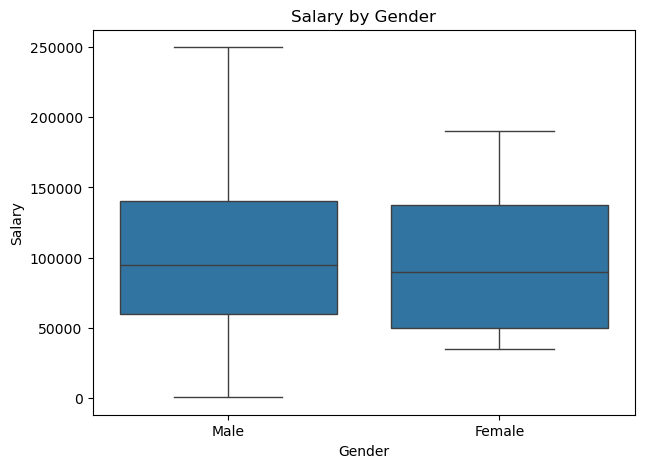

In [12]:
# ===========================================
# Visualization 6: Salary by Gender
# Purpose:
# Compares salary distributions across different
# gender groups using boxplots.
# ===========================================

plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Salary by Gender")
plt.show()

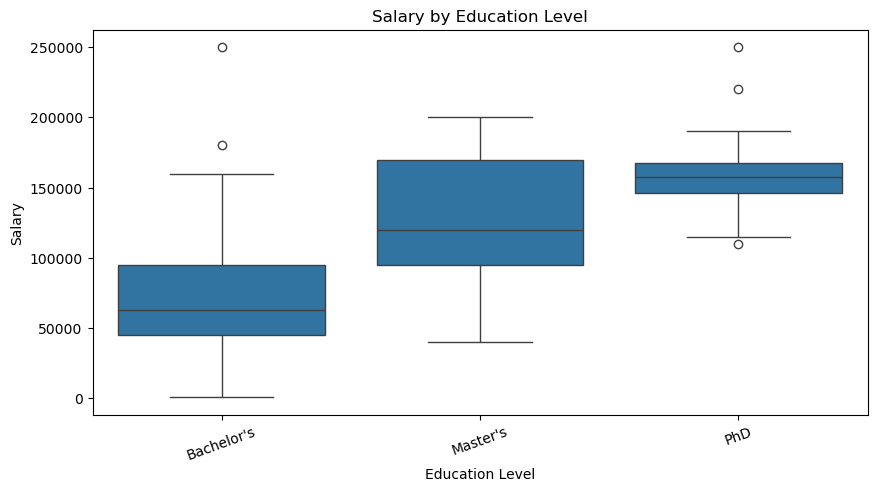

In [13]:
# ===========================================
# Visualization 7: Salary by Education Level
# Purpose:
# Compares salaries among different education
# levels to determine whether higher education
# is associated with higher salaries.
# ===========================================

plt.figure(figsize=(10,5))
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.xticks(rotation=20)
plt.title("Salary by Education Level")
plt.show()

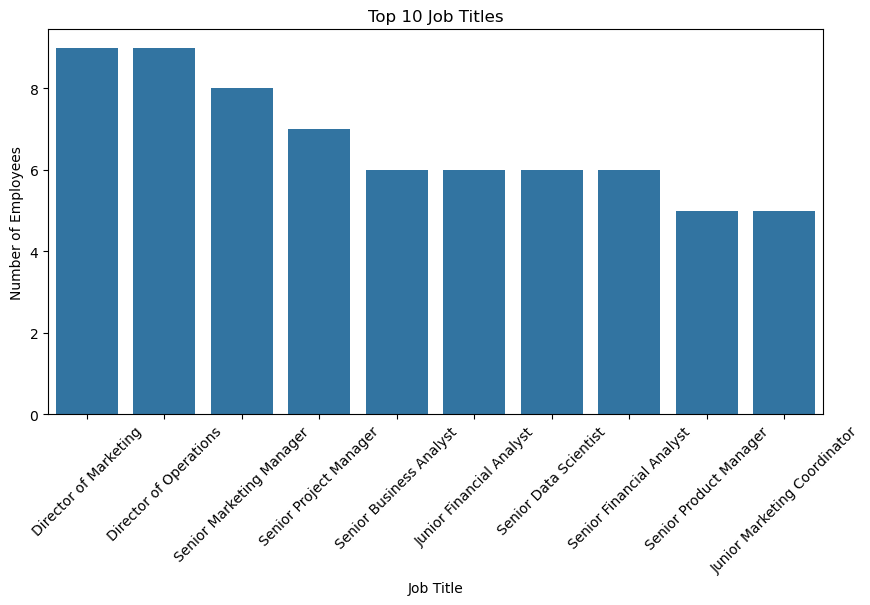

In [14]:
# ===========================================
# Visualization 8: Top 10 Job Titles
# Purpose:
# Displays the ten most common job titles
# in the dataset.
# ===========================================

top_jobs = df['Job Title'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_jobs.index, y=top_jobs.values)
plt.xticks(rotation=45)
plt.xlabel("Job Title")
plt.ylabel("Number of Employees")
plt.title("Top 10 Job Titles")
plt.show()

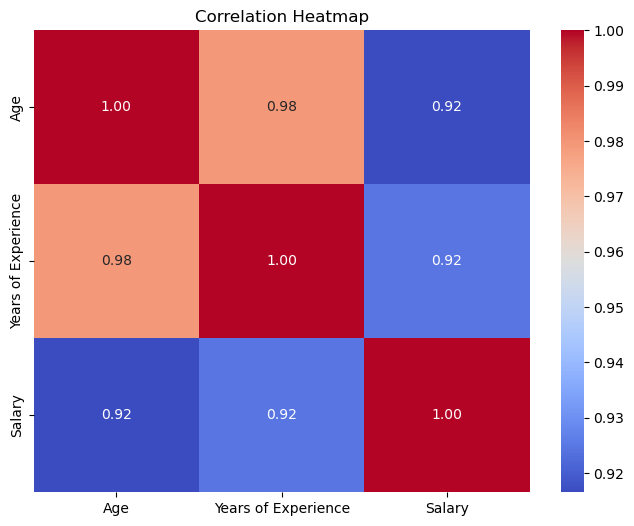

In [15]:
# ===========================================
# Visualization 9: Correlation Heatmap
# Purpose:
# Shows the strength of relationships among
# numerical variables such as Age, Experience,
# and Salary.
#
# Values close to +1 indicate strong positive
# correlation, values close to -1 indicate
# strong negative correlation, and values near
# 0 indicate little or no relationship.
# ===========================================

plt.figure(figsize=(8,6))
corr = df[['Age','Years of Experience','Salary']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

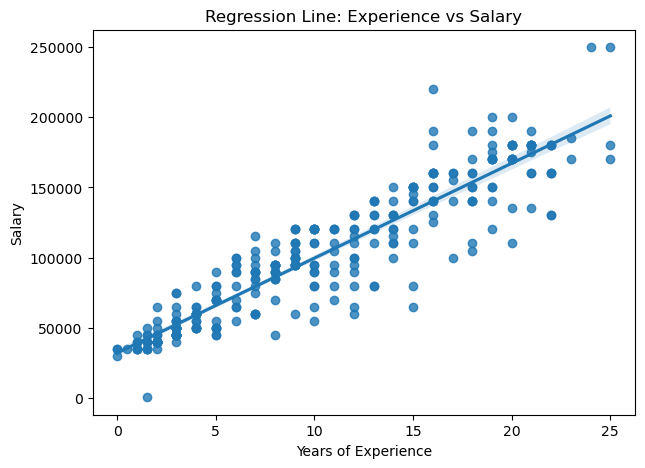

In [16]:
# ===========================================
# Visualization 10: Regression Plot
# Purpose:
# Displays the trend line between years of
# experience and salary to help understand
# whether salary generally increases with
# experience.
# ===========================================

plt.figure(figsize=(7,5))
sns.regplot(x='Years of Experience',
            y='Salary',
            data=df)

plt.title("Regression Line: Experience vs Salary")
plt.show()